# Day 4 — Building & Training a Network in Keras

## Step 1 — Build a Keras Sequential Neural Network

A Keras Sequential Neural Network is built for the Cardiac Disease Prediction task.

The network contains:

- An input layer based on the number of input features.
- A hidden layer with 64 neurons and ReLU activation.
- A second hidden layer with 32 neurons and ReLU activation.
- One output neuron with Sigmoid activation for binary classification.

In [1]:
import tensorflow as tf


## Data Loading, Feature Separation, and Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\Hp\Desktop\binx_mohammadabuhamed\binx_mohammadabuhamed\Cardiac Patients\data\dataprocessed_heart_data.csv")
X=df.drop('has_heart_disease',axis=1)
y=df['has_heart_disease']
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
catcols=X.select_dtypes(include='object').columns
numcols=X.select_dtypes(exclude='object').columns


C:\Users\Hp\AppData\Local\Temp\ipykernel_23756\1732489969.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catcols=X.select_dtypes(include='object').columns


### Create the Preprocessing Pipeline

In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
preprocceser=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numcols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),catcols)
    ]
    
)

### Fit the Preprocessor and Transform the Training Data

In [4]:
X_train_pre=preprocceser.fit_transform(X_train)
X_test_pre=preprocceser.transform(X_test)

### Get the Number of Input Features

In [5]:
n_features = X_train_pre.shape[1]

print("Number of input features:", n_features)

Number of input features: 31


### Build the Initial Keras Sequential Model

In [6]:
model=tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])


### Model Architecture

The initial Neural Network contains two hidden layers with 64 and 32 neurons.

ReLU is used in the hidden layers, while Sigmoid is used in the output layer because the project is a binary classification task.

The numbers of hidden layers and neurons are initial design choices and are not assumed to be optimal.

## Step 2 — Compile and Train the Neural Network

### Compile the Model with Adam and Binary Cross-Entropy

In [7]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",tf.keras.metrics.Recall(name='recall')]
)

The model is compiled using the Adam optimizer and Binary Cross-Entropy loss because the project is a binary classification task.

Accuracy and revall are also tracked during training to monitor the model's performance.

### Train the Neural Network

In [8]:
history=model.fit(X_train_pre,y_train,validation_split=0.2,epochs=30,batch_size=32)

Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8401 - loss: 0.3620 - recall: 0.6126 - val_accuracy: 0.8889 - val_loss: 0.2829 - val_recall: 0.7418
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8931 - loss: 0.2588 - recall: 0.7862 - val_accuracy: 0.8903 - val_loss: 0.2690 - val_recall: 0.7488
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8991 - loss: 0.2436 - recall: 0.7994 - val_accuracy: 0.8924 - val_loss: 0.2667 - val_recall: 0.7606
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9014 - loss: 0.2362 - recall: 0.8034 - val_accuracy: 0.8931 - val_loss: 0.2670 - val_recall: 0.7606
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9028 - loss: 0.2307 - recall: 0.8063 - val_accuracy: 0.8924 - val_loss: 0.2673 - val_recall: 0.7559
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9043 - loss: 0.2261 - recall: 0.8092 - val_accuracy: 0.8938 - val_loss: 0.2681 - val_recall: 0.7606
Epoc

## Step 3 — Plot Training and Validation Performance

### 3.1 Plot Training and Validation Loss

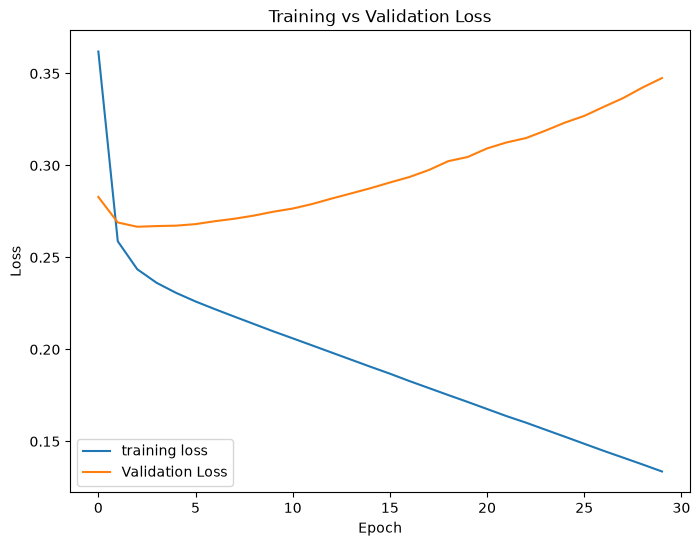

In [9]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'],label="training loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Loss Curve Interpretation

The training loss continues to decrease throughout the training process, showing that the Neural Network is learning the training data well.

However, the validation loss decreases only during the first few epochs and then starts to increase.

This indicates overfitting. The model continues improving on the training data, but its performance on unseen validation data becomes worse.

The best validation performance appears to occur during the early epochs before the validation loss begins to rise.

### 3.2 Plot Training and Validation Accuracy

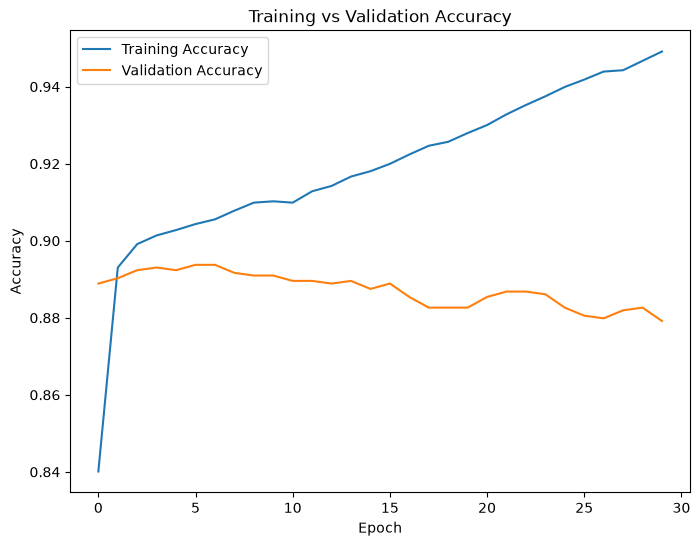

In [10]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

### Accuracy Curve Interpretation

The training accuracy continues to increase throughout the epochs, reaching approximately 95%.

The validation accuracy improves only during the early epochs and then remains almost stable before decreasing slightly.

This difference between training and validation accuracy supports the conclusion that the model is overfitting.

The model is becoming increasingly accurate on the training data, but its ability to generalize to unseen validation data is not improving.

### 3.3 Plot Training and Validation Recall

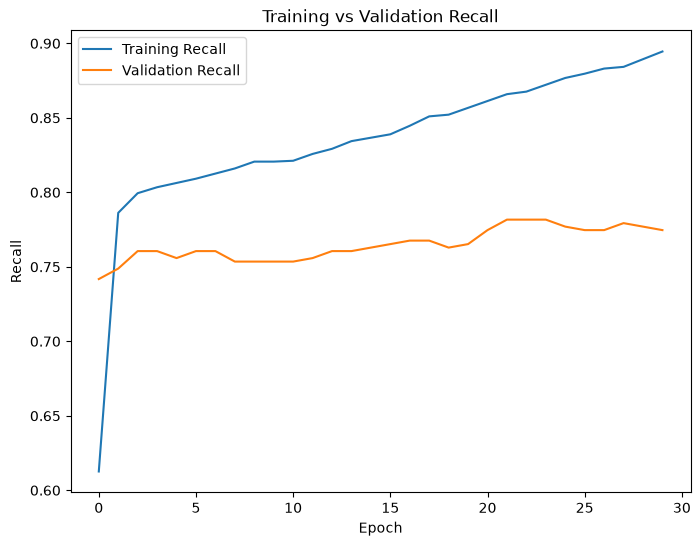

In [11]:
plt.figure(figsize=(8, 6))

plt.plot(history.history["recall"], label="Training Recall")
plt.plot(history.history["val_recall"], label="Validation Recall")

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall")
plt.legend()

plt.show()

### Recall Curve Interpretation

The training recall continues to increase throughout the epochs, reaching approximately 0.89.

The validation recall improves slightly during the early epochs but then remains relatively stable around 0.75–0.78.

The growing gap between training recall and validation recall is another sign of overfitting.

The model is learning the training data increasingly well, but its ability to detect positive cases in unseen validation data is not improving at the same rate.

## Step 4 — Add Dropout and Batch Normalization

The first Neural Network showed signs of overfitting.

To reduce overfitting and improve training stability, Batch Normalization and Dropout are added to a new version of the network.

### 4.1 Build the Regularized Model

In [12]:
model_regularized = tf.keras.Sequential([
    tf.keras.Input(shape=(n_features,)),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

### 4.2 Compile the Regularized Model

In [13]:
model_regularized.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Recall(name="recall")
    ]
)

4.3 Train the Regularized Model

In [14]:
history_regularized = model_regularized.fit(
    X_train_pre,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32
)

Epoch 1/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7625 - loss: 0.5059 - recall: 0.7536 - val_accuracy: 0.8674 - val_loss: 0.3310 - val_recall: 0.6808
Epoch 2/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8514 - loss: 0.3565 - recall: 0.7461 - val_accuracy: 0.8861 - val_loss: 0.2871 - val_recall: 0.7300
Epoch 3/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8740 - loss: 0.3150 - recall: 0.7593 - val_accuracy: 0.8903 - val_loss: 0.2745 - val_recall: 0.7418
Epoch 4/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8774 - loss: 0.2943 - recall: 0.7542 - val_accuracy: 0.8965 - val_loss: 0.2692 - val_recall: 0.7512
Epoch 5/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8826 - loss: 0.2860 - recall: 0.7650 - val_accuracy: 0.8944 - val_loss: 0.2675 - val_recall: 0.7465
Epoch 6/30
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8859 - loss: 0.2788 - recall: 0.7673 - val_accuracy: 0.9000 - val_loss: 0.2656 - val_recall: 0.7559
Epoc

### 4.4 Compare Original and Regularized Validation Loss

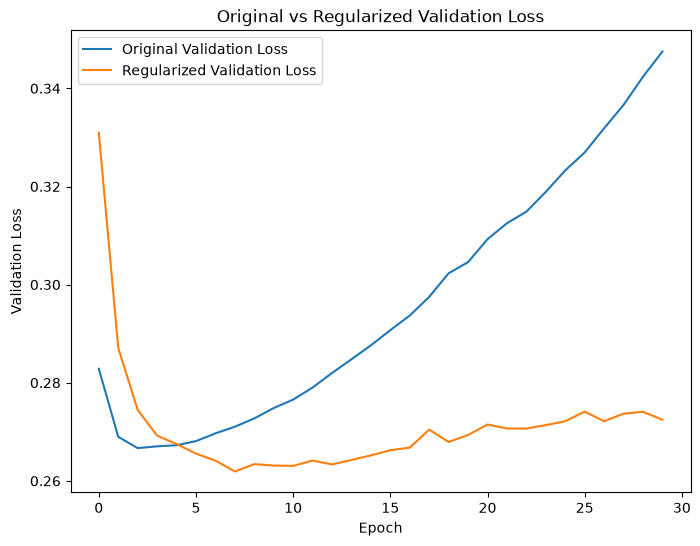

In [15]:
plt.figure(figsize=(8, 6))
plt.plot(
    history.history["val_loss"],
    label="Original Validation Loss"
)
plt.plot(
    history_regularized.history["val_loss"],
    label="Regularized Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Original vs Regularized Validation Loss")
plt.legend()
plt.show()

### Regularization Comparison Interpretation

The regularized model produced a lower and more stable validation loss than the original model.

The original model started to overfit after the first few epochs, as its validation loss continued to increase.

After adding Dropout and Batch Normalization, the validation loss decreased further and remained relatively stable for most of the training process.

This indicates that the regularization techniques reduced overfitting and improved the model's ability to generalize to unseen data.

### 4.5 Compare Original and Regularized Validation recall

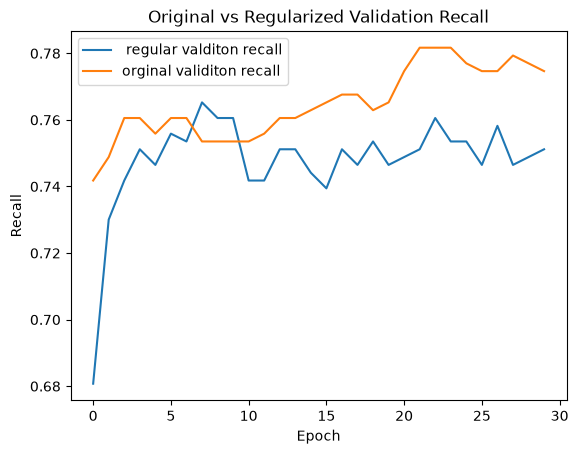

In [21]:
plt.Figure(figsize=(8,6))
plt.plot(history_regularized.history['val_recall'],label=" regular valditon recall")
plt.plot(history.history['val_recall'],label="orginal validiton recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Original vs Regularized Validation Recall")
plt.legend()
plt.show()

### Validation Recall Comparison

The original model achieved slightly higher validation recall than the regularized model.

After adding Dropout and Batch Normalization, the validation recall became slightly lower, even though the validation loss was more stable.

This shows that regularization reduced overfitting, but it also slightly reduced the model's ability to detect positive cases in the validation data.

Therefore, both generalization and Recall should be considered when selecting the final model.

## Step 5 — Evaluate the Neural Network on the Test Set

### 5.1 Evaluate the Original Neural Network

In [25]:
original_loss, original_accuracy, original_recall = model.evaluate(
    X_test_pre,
    y_test
)
regularized_loss, regularized_accuracy, regularized_recall = model_regularized.evaluate(
    X_test_pre,
    y_test
)
print("Original Model")
print("Loss:", original_loss)
print("Accuracy:", original_accuracy)
print("Recall:", original_recall)

print("\nRegularized Model")
print("Loss:", regularized_loss)
print("Accuracy:", regularized_accuracy)
print("Recall:", regularized_recall)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8811 - loss: 0.3300 - recall: 0.7896
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8933 - loss: 0.2541 - recall: 0.7932
Original Model
Loss: 0.3300263583660126
Accuracy: 0.8811110854148865
Recall: 0.7895683646202087

Regularized Model
Loss: 0.25414738059043884
Accuracy: 0.8933333158493042
Recall: 0.7931654453277588


### 5.3 Compare the Neural Network with the Day 1 Baseline

The regularized Neural Network performed better than the original Neural Network.

The regularized model achieved a lower test loss, higher accuracy, and slightly higher recall.

| Model | Accuracy | Recall |
|---|---:|---:|
| Random Forest Baseline | 0.88 | **0.85** |
| Original Neural Network | 0.881 | 0.790 |
| Regularized Neural Network | **0.893** | 0.793 |

The regularized Neural Network achieved the highest accuracy, but the Random Forest baseline achieved the highest recall.

Since Recall is especially important for detecting positive Heart Disease cases in this project, the Random Forest remains the stronger model according to the selected priority metric.

The experiment also shows that adding Dropout and Batch Normalization improved the Neural Network compared with the original architecture.